In [1]:
""" Created on April 24, 2026 // @author: Sarah Shi """

import numpy as np
import sys 
sys.path.append('../../src/')
import mineralML as mm

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# Interactive Tools for Mapped EDS Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SarahShi/mineralML/blob/main/docs/examples/mineralML_interactive.ipynb)

This notebook demonstrates **interactive tools for exploring mineralML phase maps**. These tools require a live Python kernel and an interactive Matplotlib backend — they cannot be run on ReadTheDocs. Use the Colab badge above or run locally with `%matplotlib widget` (requires `ipympl`).

```bash
pip install ipympl
```

The tools shown here are:

- **`mm.interactive_pixels`** — click pixels to sample oxide compositions
- **`mm.interactive_line_profile`** — click to draw transects and extract line profiles
- **`mm.plot_locations`** — plot the locations of picked pixels or transects on a map

## 1. Load and run a map

First, run `mm.run_map` as usual to get the result dictionary. See the [EDS mapping notebook](mineralML_mapping.ipynb) for full details on loading and preparing data.

[ok] Mg Wt%Montaged Map Data.csv  →  Mg  (329, 283)
[ok] Ca Wt%Montaged Map Data.csv  →  Ca  (329, 283)
[ok] Al Wt%Montaged Map Data.csv  →  Al  (329, 283)
[ok] Fe Wt%Montaged Map Data.csv  →  Fe  (329, 283)
[ok] Na Wt%Montaged Map Data.csv  →  Na  (329, 283)
[ok] Mn Wt%Montaged Map Data.csv  →  Mn  (329, 283)
[ok] Cr Wt%Montaged Map Data.csv  →  Cr  (329, 283)
[ok] Ti Wt%Montaged Map Data.csv  →  Ti  (329, 283)
[ok] Si Wt%Montaged Map Data.csv  →  Si  (329, 283)
[ok] K Wt%Montaged Map Data.csv  →  K  (329, 283)
mineralML: 93107 rows — 57732 classified by neural network, 0 by empirical rules (Zircon: 0, SiO2 polymorph: 0, Carbonate: 0), 35375 skipped (invalid/empty)
prep_df: 57732 row(s) processed (of 57732 input, 0 dropped).


/Users/sarahshi/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:313: UserWarning: The following columns were missing and have been filled with NaN: ['Mineral']
  df = prep_df(df)


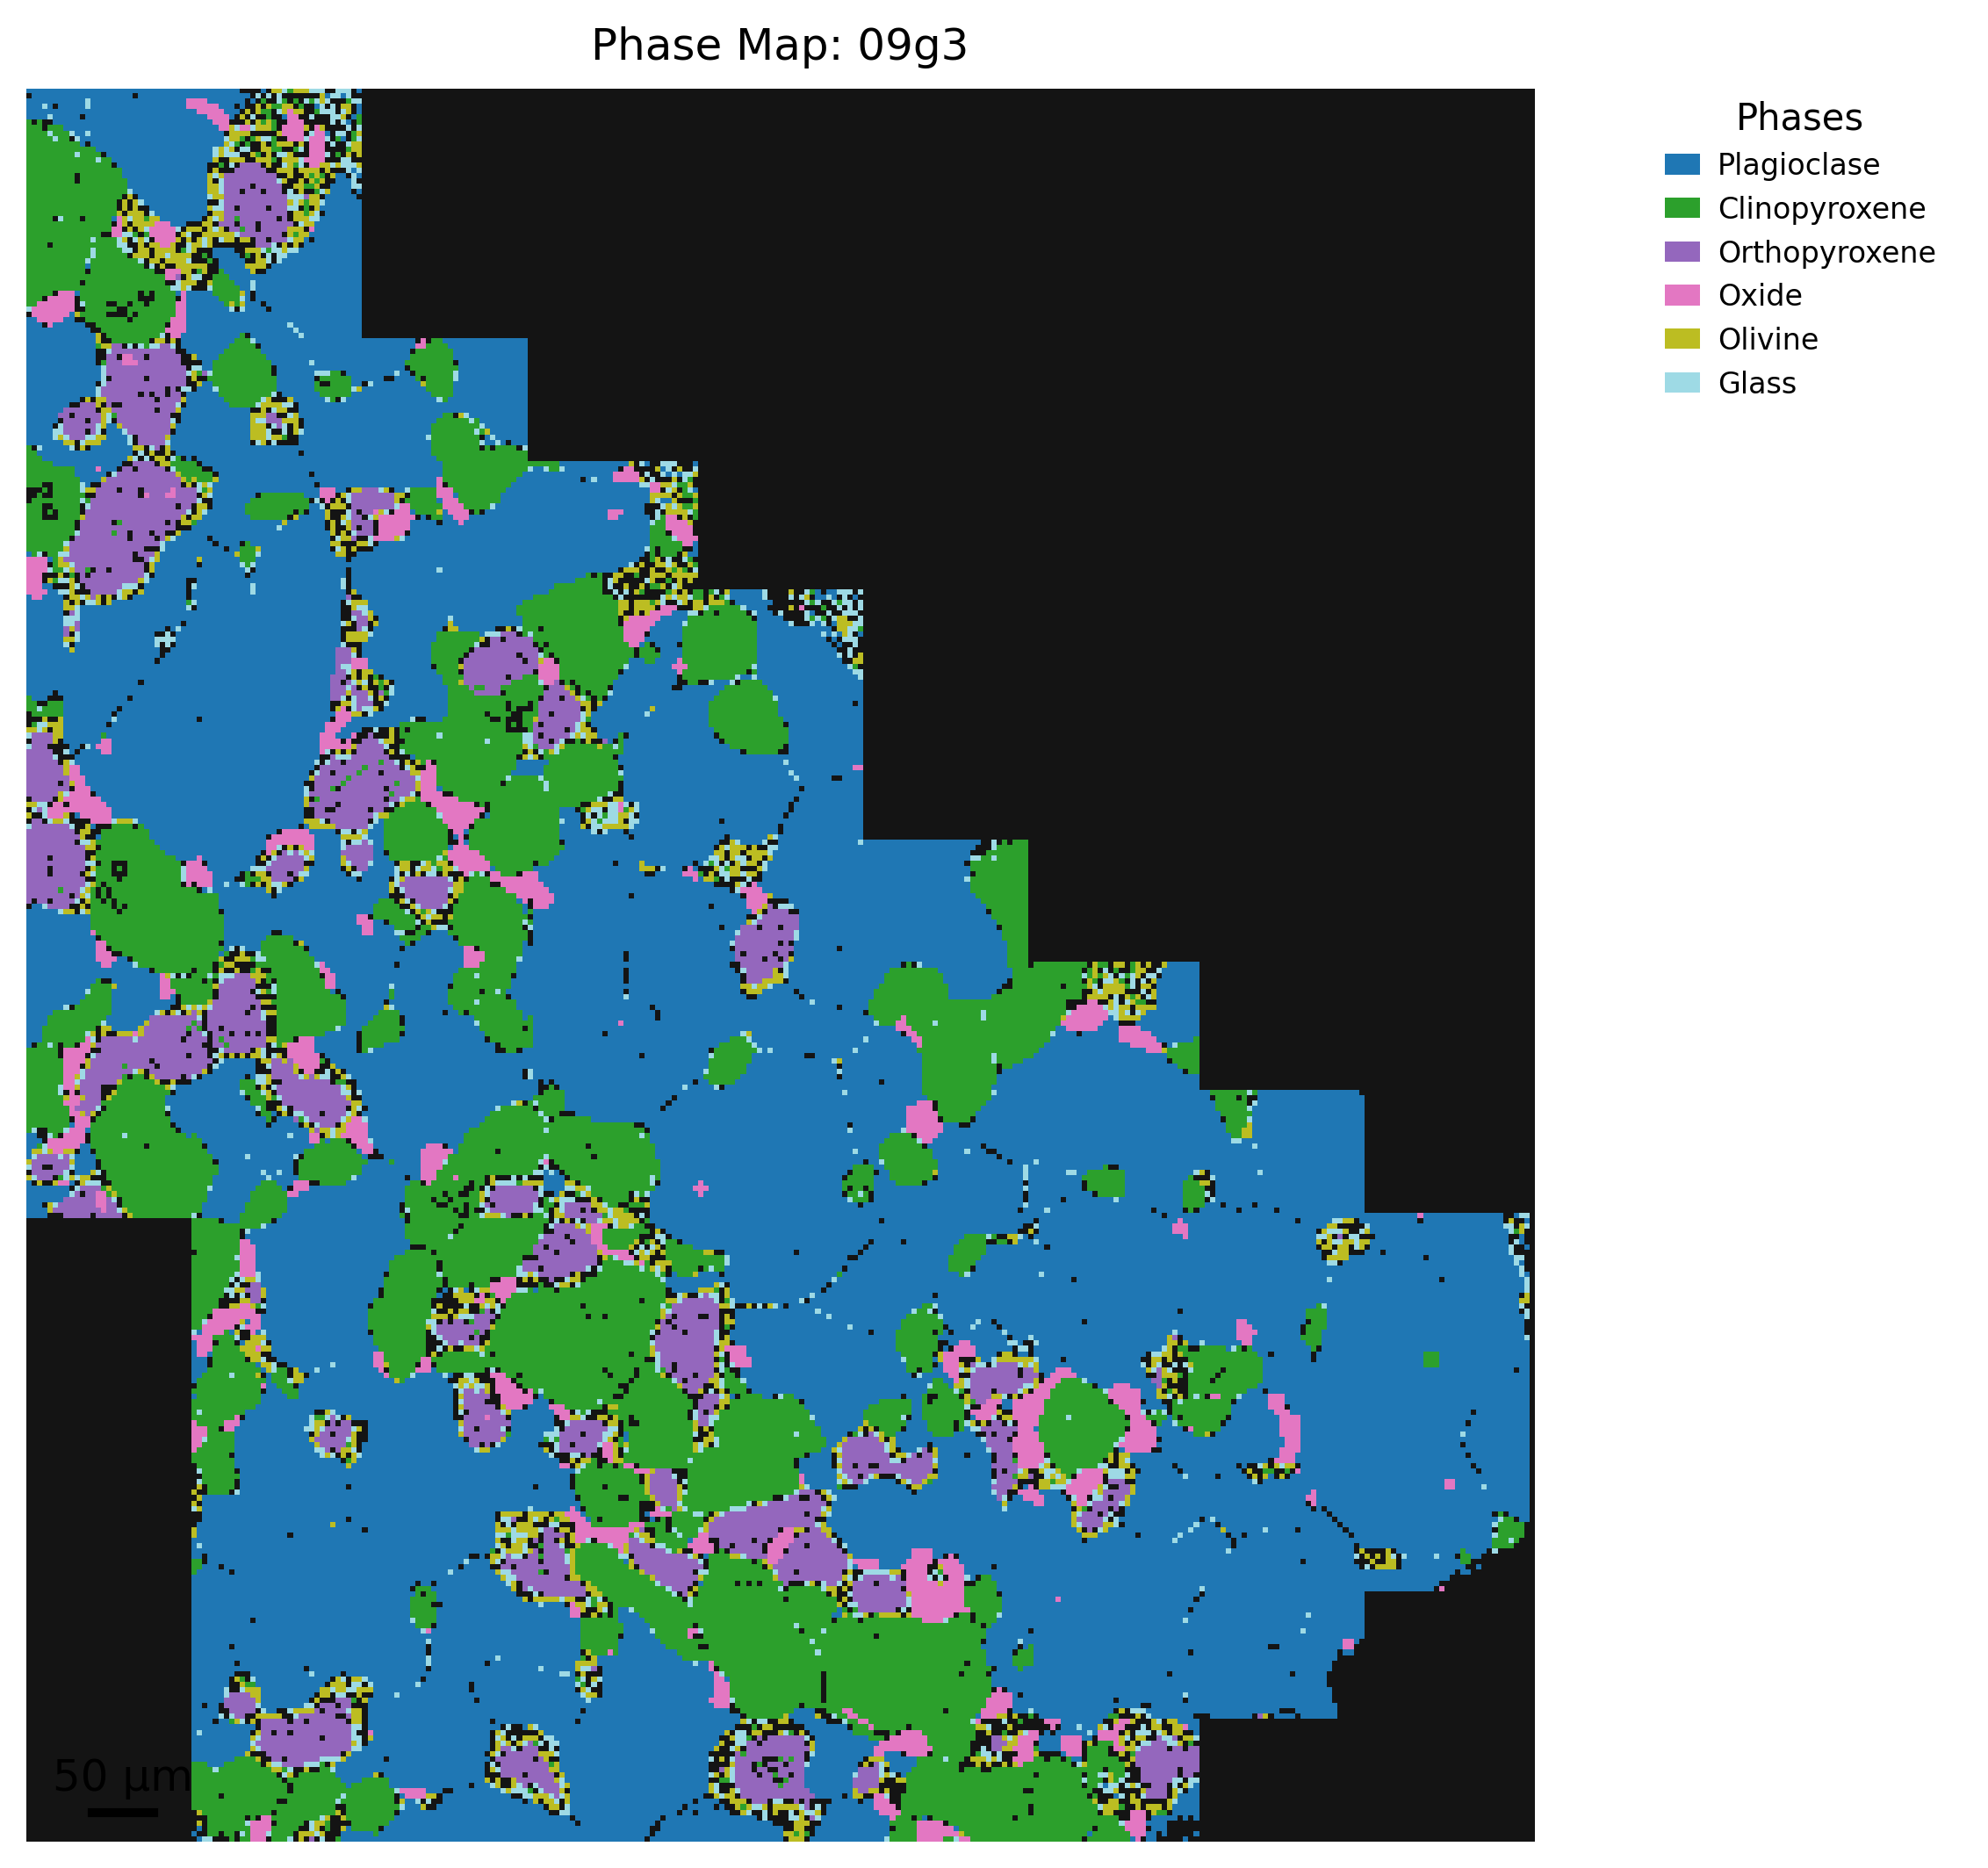

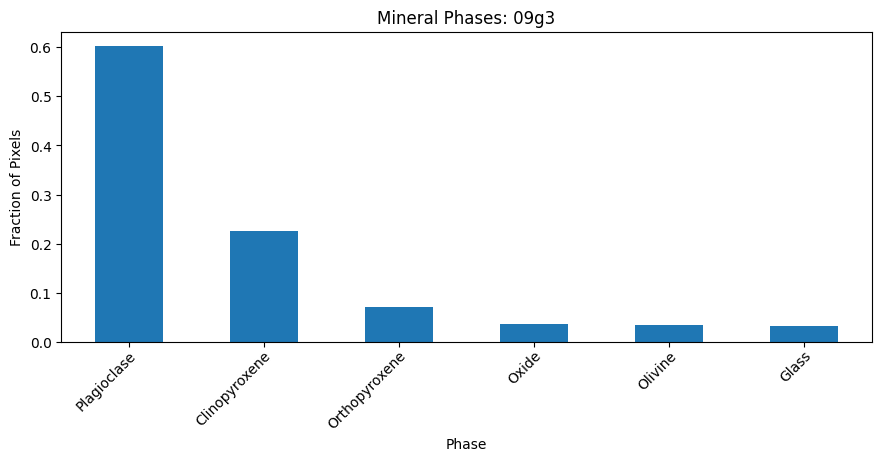

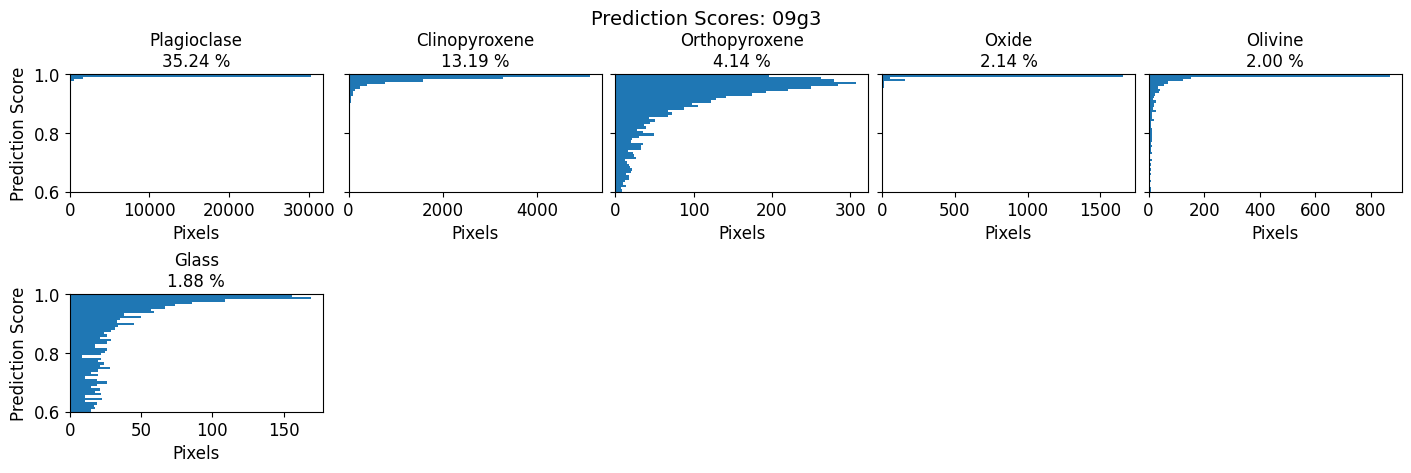

In [2]:
%matplotlib inline

result = mm.run_map(
    "Maps/09g3",
    renormalize=True,
    units="element_wt%",
    pixel_size_um=4.0,
    scalebar_um=50,
    total_threshold=50,
    min_frac=0.01,
)

## 2. Interactive pixel composition picker

`mm.interactive_pixels` displays the phase map and records the full oxide composition of each pixel you click. Each click:
- Places a marker on the map
- Prints the oxide values below the figure
- Appends a row to the dataframe in `controller["picks"]`

**Keybindings:** `r`/`u` undo last pick &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

After quitting, access your picks as a DataFrame:
```python
controller["picks"]
```

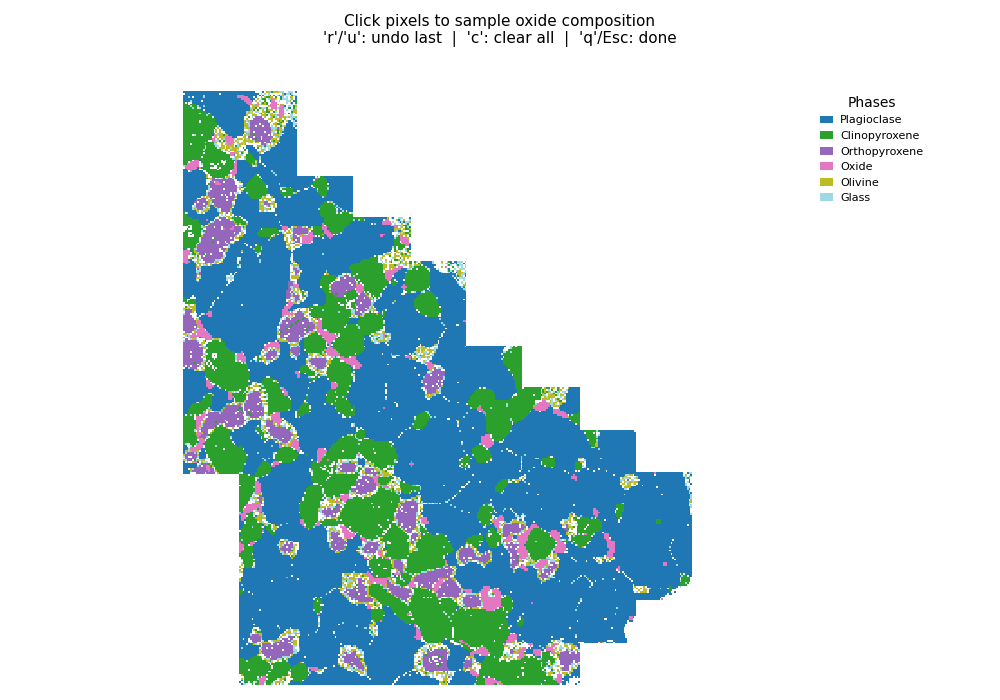

Output()

In [3]:
%matplotlib widget

controller = mm.interactive_pixels(result,
                                   region=5, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                   phase=None, # specify phase to display (e.g. "Plagioclase" or "plagioclase", case-insensitive; warns if not found in the map); if None, will display all pixels regardless of phase assignment
                                   )

In [4]:
%matplotlib inline

controller["picks"]

,x,y,phase,n_pixels,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,Total,Total_raw
0,38,126,Plagioclase,25,51.617822,0.011785,30.908446,0.140818,0.010653,0.115163,12.861216,4.080847,0.297884,-0.044633,100.0,98.966231
1,25,156,Clinopyroxene,25,49.511871,0.772974,7.983220,6.854021,0.075449,13.672612,20.220016,0.800171,0.077612,0.032054,100.0,99.698521
2,27,179,Orthopyroxene,24,51.590014,0.186965,6.423261,14.383120,0.057600,26.163999,0.872904,0.181970,0.028170,0.111996,100.0,100.132241
3,169,283,Oxide,25,-0.187194,0.191801,60.614088,21.867168,-0.078233,16.200129,0.058149,0.127518,-0.018396,1.224971,100.0,96.453630


### 2a. Filter to a specific phase

Pass `phase` to restrict the display and clicks to one or more mineral phases. Pixels outside the selected phase are shown as white background.

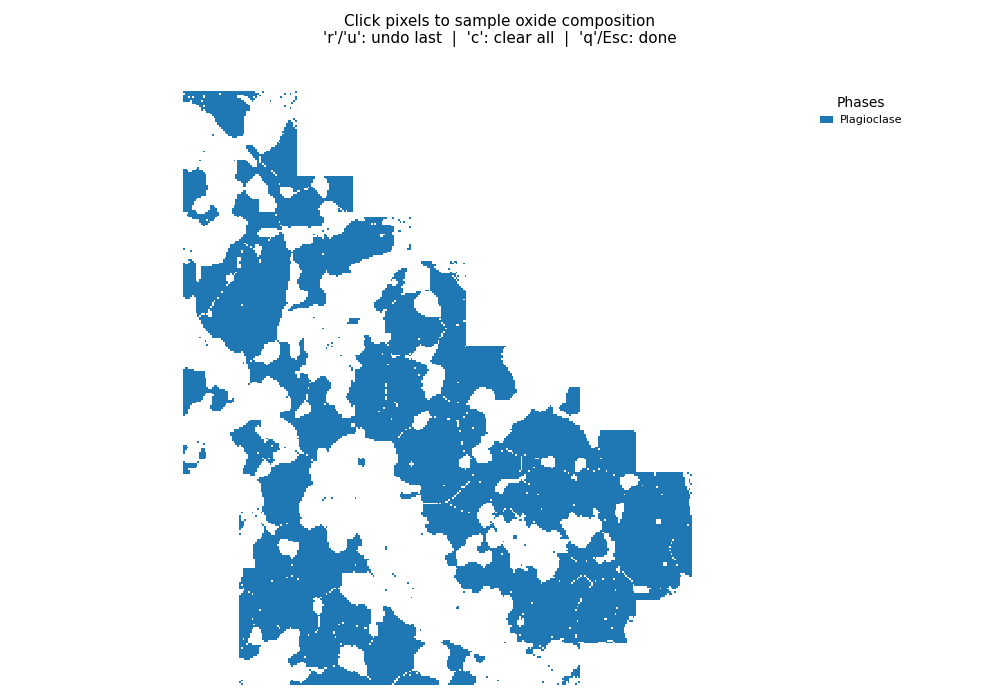

Output()

In [ ]:
%matplotlib widget

controller_plag = mm.interactive_pixels(result,
                                        region=5, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                        phase="Plagioclase" # plot only pixels classified as plagioclase (optional; if None, will display all pixels regardless of phase assignment
                                        )

### 2b. Display an oxide heatmap as background

Pass `oxide_key` to show an oxide or component concentration map instead of the phase map. Combine with `phase` to restrict to a single mineral.

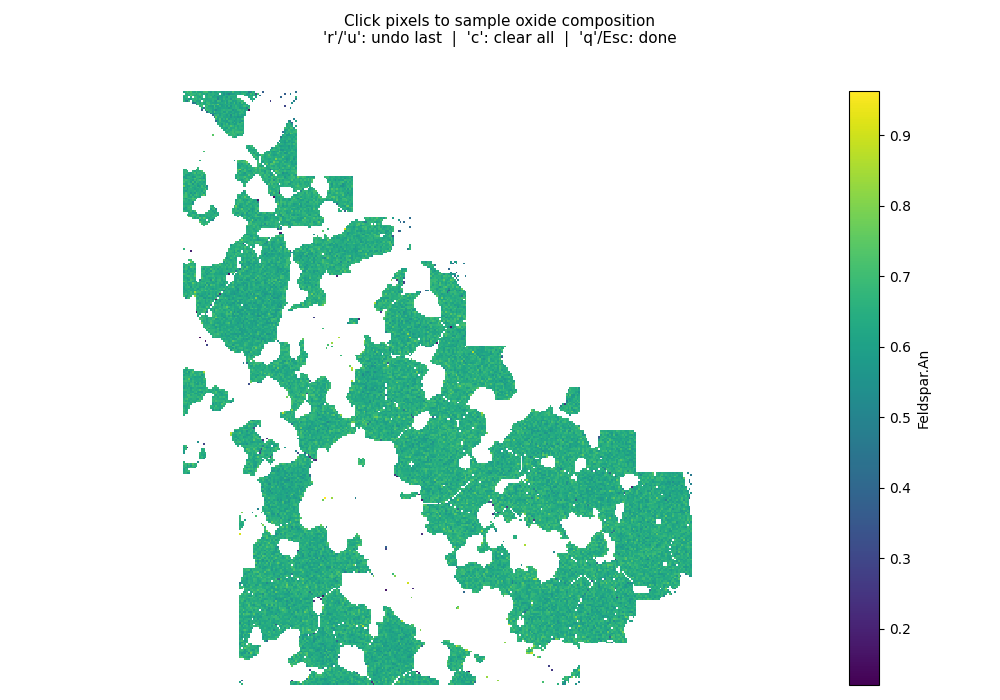

Output()

In [6]:
%matplotlib widget

controller_sio2 = mm.interactive_pixels(result,
                                        region=5, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                        oxide_key="Feldspar.An", # plot An content of each pixel instead of phase assignment
                                        phase="Plagioclase" # plot only pixels classified as plagioclase (optional; if None, will display all pixels regardless of phase assignment
                                        )

## 3. Plot pick locations

`mm.plot_locations` overlays picked pixel locations on a map. Pass `map_key` to use an oxide map as the background.

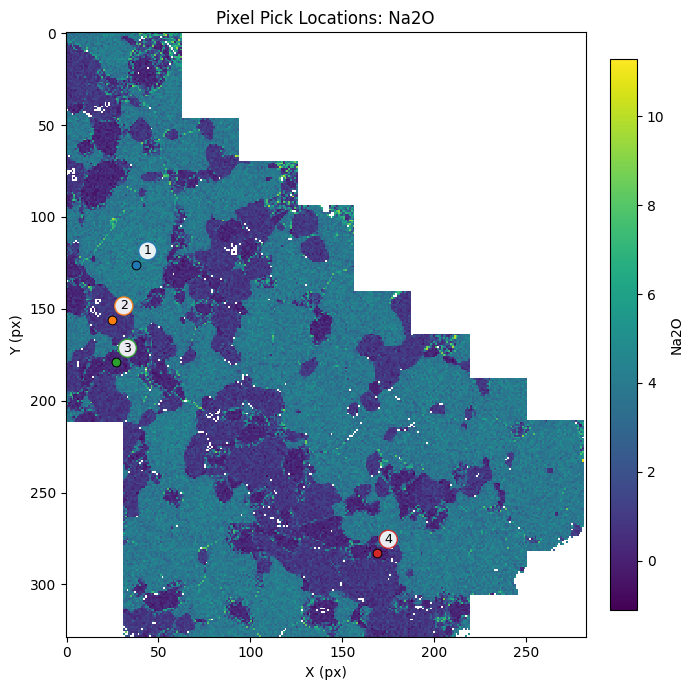

In [7]:
%matplotlib inline

# plotting region associated with the original controller
fig, ax = mm.plot_locations(result,
                            controller["picks"], # plot only the pixels that have been picked
                            map_key="Na2O", # color the points by their Na2O content
                            )

## 4. Interactive region selection

`mm.interactive_region` lets you drag out a rectangular box on a map to extract every pixel inside it. Each completed box is summarized (mean, median, std, min, max, n_pixels) and its raw pixels are kept for later use.

**Keybindings:** `r` reset current box &nbsp;|&nbsp; `u` undo last region &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

Access results after quitting:
```python
reg["regions_df"]   # summary stats, one row per box
reg["samples_df"]   # raw pixel values for all boxes
```

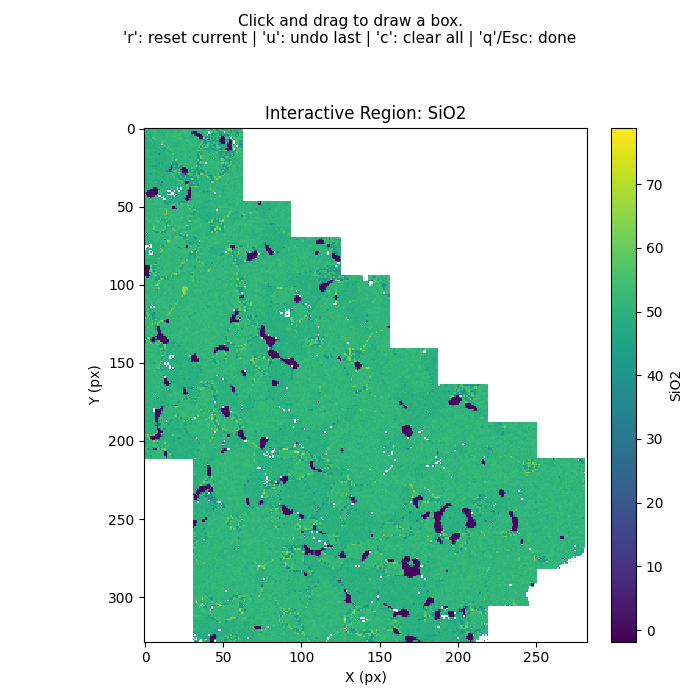

In [8]:
%matplotlib widget

region = mm.interactive_region(
    result,
    key="SiO2", # key of the oxide map to plot and sample from
    pixel_size_um=4.0, # pixel size in micrometers
    include_oxides=True, # returns all oxide data, not just the key selected
)

In [9]:
%matplotlib inline

display(region["regions_df"])   # summary stats, one row per box

display(region["samples_df"])   # raw pixel values for all boxes

,region_id,key,source,x0,y0,x1,y1,width_px,height_px,area_px2,...,mean_Al2O3,mean_FeOt,mean_MnO,mean_MgO,mean_CaO,mean_Na2O,mean_K2O,mean_Cr2O3,mean_Total,mean_Total_raw
0,1,SiO2,auto,32,114,44,126,11.521650,12.161741,140.123327,...,31.060310,0.212078,-0.053976,0.113134,12.934332,4.076912,0.267948,-0.039046,100.0,98.786521
1,2,SiO2,auto,77,134,83,139,5.760825,5.120733,29.499648,...,44.277095,16.774169,0.016719,15.047353,6.508193,0.563052,0.075664,0.915488,100.0,97.424228
2,3,SiO2,auto,148,234,164,249,16.002291,14.722108,235.587465,...,28.272543,1.065989,-0.050228,1.837050,14.214813,3.477639,0.254745,-0.033417,100.0,98.504159


,x,y,value,phase,region_id,key,source,color,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,Total,Total_raw
0,32,113,52.753350,Plagioclase,1,SiO2,auto,#1f77b4,52.753350,-0.067686,29.415176,-0.530647,-0.265236,0.650691,13.231832,4.584467,0.090662,0.137389,100.0,94.361119
1,33,113,50.901775,Plagioclase,1,SiO2,auto,#1f77b4,50.901775,-0.039842,32.100941,0.811811,-0.142051,0.018787,12.359680,3.596828,0.320120,0.071953,100.0,100.537349
2,34,113,50.058924,Plagioclase,1,SiO2,auto,#1f77b4,50.058924,-0.089873,31.536426,-0.145641,0.466009,0.095711,13.547475,4.593723,0.178510,-0.241264,100.0,101.332137
3,35,113,51.369574,Plagioclase,1,SiO2,auto,#1f77b4,51.369574,0.424520,31.232987,0.042859,0.416710,0.084247,12.171055,4.709116,-0.067593,-0.383474,100.0,103.118605
4,36,113,50.885635,Plagioclase,1,SiO2,auto,#1f77b4,50.885635,0.637572,31.676989,0.264478,-0.328128,0.360056,12.584883,4.065958,0.082461,-0.229903,100.0,100.300505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,160,249,50.071372,Clinopyroxene,3,SiO2,auto,#2ca02c,50.071372,0.287335,9.170200,6.409733,-0.175713,13.733457,18.950960,1.412259,0.281655,-0.141258,100.0,99.900501
522,161,249,50.661530,Clinopyroxene,3,SiO2,auto,#2ca02c,50.661530,0.623962,6.925232,6.705807,0.199142,14.818966,19.397067,1.005384,-0.184616,-0.152474,100.0,96.135046
523,162,249,50.647671,Clinopyroxene,3,SiO2,auto,#2ca02c,50.647671,0.831053,7.647534,6.421391,0.151228,13.494031,20.100913,0.682057,0.228921,-0.204800,100.0,100.816955
524,163,249,48.492264,Clinopyroxene,3,SiO2,auto,#2ca02c,48.492264,0.918801,7.801939,6.982960,-0.202241,13.255981,21.465773,0.975327,0.209170,0.100027,100.0,98.565192


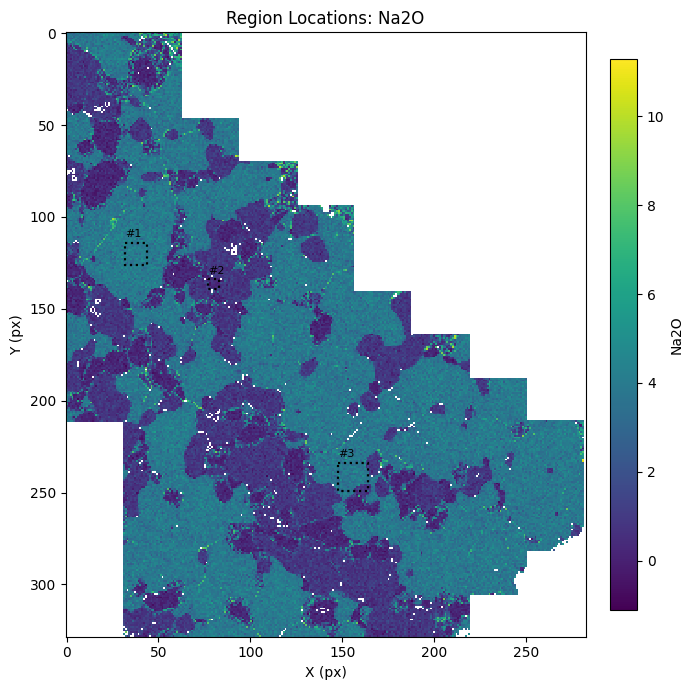

In [10]:
fig, ax = mm.plot_locations(result,
                            region["regions_df"],   # plot all drawn boxes
                            map_key="Na2O",       # color background by Na2O content
                            )

### 4a. Filter regions to a single phase

Pass `phase` to mask the background map to pixels of a specific mineral before drawing boxes. Pixels outside the selected phase are excluded from the stats even if they fall inside a drawn box.

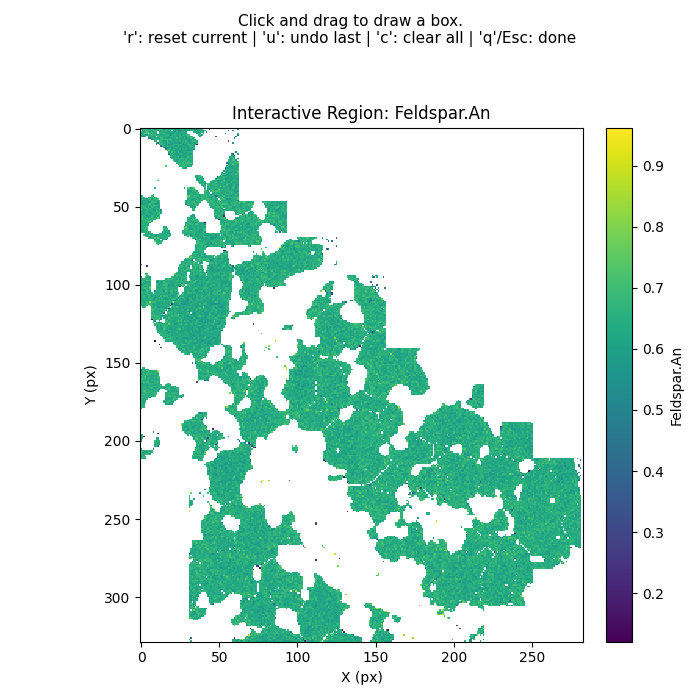

In [11]:
%matplotlib widget

region_plag = mm.interactive_region(
    result,
    key="Feldspar.An", # plot the An content of pixels classified as plagioclase
    phase="Plagioclase",
    pixel_size_um=4.0,
    include_oxides=True, # returns all oxide data, not just the key selected
)

Return the region summary and sample dataframes.

In [12]:
%matplotlib inline

display(region_plag["regions_df"])   # summary stats, one row per box

display(region_plag["samples_df"])   # raw pixel values for all boxes

,region_id,key,source,x0,y0,x1,y1,width_px,height_px,area_px2,...,mean_Al2O3,mean_FeOt,mean_MnO,mean_MgO,mean_CaO,mean_Na2O,mean_K2O,mean_Cr2O3,mean_Total,mean_Total_raw
0,1,Feldspar.An,auto,28,121,38,131,10.241467,9.601375,98.332159,...,31.038634,0.260837,-0.037080,0.146940,12.792949,4.139705,0.292553,-0.046405,100.0,99.367258
1,2,Feldspar.An,auto,149,148,156,156,7.041008,8.321192,58.589578,...,31.274687,0.262095,-0.024379,0.088063,13.188586,3.998500,0.263274,-0.074961,100.0,99.806448
2,3,Feldspar.An,auto,196,217,208,229,12.161741,11.521650,140.123327,...,31.174530,0.242509,-0.021135,0.161487,13.194285,3.942193,0.275301,-0.047579,100.0,99.331307


,x,y,value,phase,region_id,key,source,color,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,Total,Total_raw
0,28,121,0.598415,Plagioclase,1,Feldspar.An,auto,#1f77b4,49.785459,0.086509,31.172703,0.402689,0.334320,0.462334,12.893268,4.612030,0.257547,-0.006859,100.0,103.318992
1,29,121,0.627106,Plagioclase,1,Feldspar.An,auto,#1f77b4,50.488094,0.261089,30.865075,0.159137,0.425484,0.137177,13.184011,4.332287,-0.117019,0.264666,100.0,99.363140
2,30,121,0.620584,Plagioclase,1,Feldspar.An,auto,#1f77b4,52.012751,0.039552,31.409131,0.467119,0.032306,0.617133,11.094798,3.398843,0.531443,0.396924,100.0,98.888574
3,31,121,0.597193,Plagioclase,1,Feldspar.An,auto,#1f77b4,51.860140,0.296722,30.736415,0.224898,-0.288979,-0.187171,12.494824,4.560608,0.147030,0.155513,100.0,101.472034
4,32,121,0.578171,Plagioclase,1,Feldspar.An,auto,#1f77b4,51.597079,0.068707,29.755308,0.123097,0.147554,0.003988,12.894219,4.968859,0.349433,0.091756,100.0,101.222325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,205,229,0.662370,Plagioclase,3,Feldspar.An,auto,#2ca02c,51.002395,-0.084645,31.477806,0.392981,0.233668,0.761572,12.772937,3.504383,0.142240,-0.203335,100.0,102.066835
424,206,229,0.639487,Plagioclase,3,Feldspar.An,auto,#2ca02c,49.670698,-0.120013,32.956274,0.030583,-0.133363,-0.074751,13.100388,4.064918,0.024906,0.480358,100.0,100.062241
425,207,229,0.602990,Plagioclase,3,Feldspar.An,auto,#2ca02c,51.746264,0.103778,31.168306,0.056296,0.305085,-0.312893,12.267123,4.127284,0.510731,0.028026,100.0,100.669750
426,208,229,0.624619,Plagioclase,3,Feldspar.An,auto,#2ca02c,53.010685,0.017418,29.512455,0.378596,-0.242188,0.608610,12.458854,3.830674,0.466663,-0.041767,100.0,102.832372


## 5. Interactive line profiles

`mm.interactive_line_profile` lets you draw transects across a map by clicking a start and end point. Each completed transect is extracted and plotted immediately.

**Keybindings:** `r` reset current clicks &nbsp;|&nbsp; `u` undo last transect &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

Access results after quitting:
```python
lp["profiles_df"]     # all profile data concatenated
lp["coordinates_df"]  # transect start/end coordinates
```

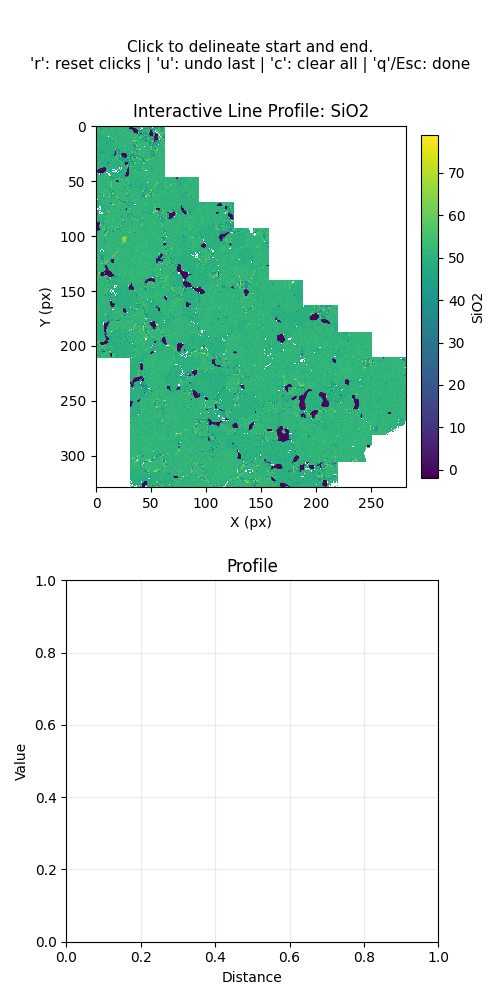

In [13]:
%matplotlib widget

lp = mm.interactive_line_profile(
    result,
    key="SiO2", # key of the oxide map to plot the line profile for
    method="none", # do not apply any smoothing to the line profile. use mean or median (across the pixel width) for a smoothed profile 
    width_px=10, # total width of the line profile in pixels
    pixel_size_um=4.0, # pixel size in micrometers
)

### 5a. Filter transects to a single phase

Pass `phase` to mask the background map to pixels of a specific mineral before drawing transects.

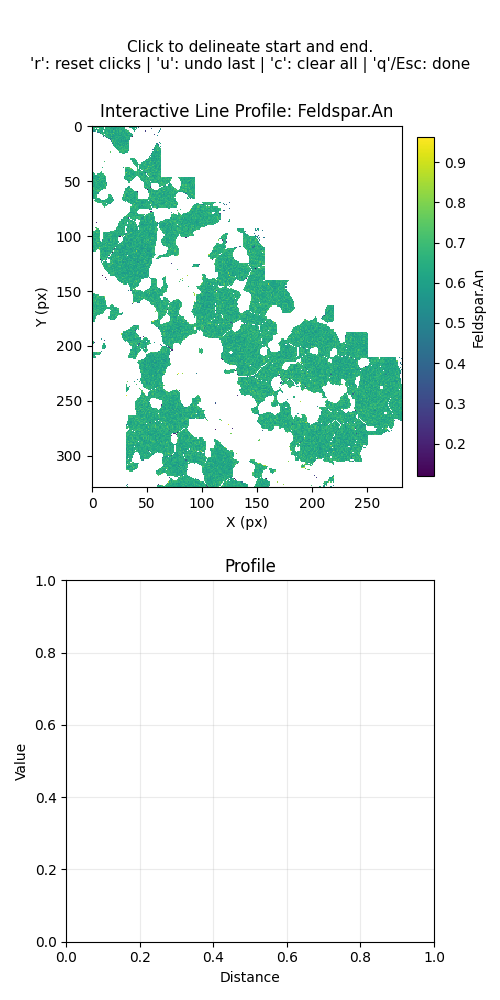

In [14]:
%matplotlib widget

lp_opx = mm.interactive_line_profile(
    result,
    key="Feldspar.An", # plot the Mg# of pixels classified as plagioclase
    phase="Plagioclase",
    method="none",
    width_px=5,
    pixel_size_um=4.0,
)

Return the line profile dataframe. 

In [15]:
%matplotlib inline

lp["profiles_df"]

,profile_id,distance_px,distance_um,SiO2,SiO2_smoothed,x,y,perp_distance_px,source,width_px,length_px,length_um,color,x0,y0,x1,y1
0,1,0.068143,0.272570,51.651112,51.651112,19.0,79.0,3.844364,auto,10.0,46.261737,185.046949,#1f77b4,23,78,31,124
1,1,0.146877,0.587509,52.636241,52.636241,25.0,78.0,-2.237889,auto,10.0,46.261737,185.046949,#1f77b4,23,78,31,124
2,1,0.245296,0.981182,49.918035,49.918035,20.0,79.0,2.860181,auto,10.0,46.261737,185.046949,#1f77b4,23,78,31,124
3,1,0.324030,1.296121,51.059962,51.059962,26.0,78.0,-3.222072,auto,10.0,46.261737,185.046949,#1f77b4,23,78,31,124
4,1,0.422449,1.689794,51.253972,51.253972,21.0,79.0,1.875998,auto,10.0,46.261737,185.046949,#1f77b4,23,78,31,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772,4,28.923226,115.692904,51.311945,51.311945,181.0,295.0,0.025161,auto,10.0,29.139219,116.556878,#d62728,152,295,181,295
1773,4,28.923226,115.692904,30.579981,30.579981,181.0,296.0,1.025161,auto,10.0,29.139219,116.556878,#d62728,152,295,181,295
1774,4,28.923226,115.692904,52.382828,52.382828,181.0,297.0,2.025161,auto,10.0,29.139219,116.556878,#d62728,152,295,181,295
1775,4,28.923226,115.692904,50.760967,50.760967,181.0,298.0,3.025161,auto,10.0,29.139219,116.556878,#d62728,152,295,181,295


## 6. Plot transect locations

Pass the `coordinates_df` from a line profile controller to `mm.plot_locations` to visualize transect positions.

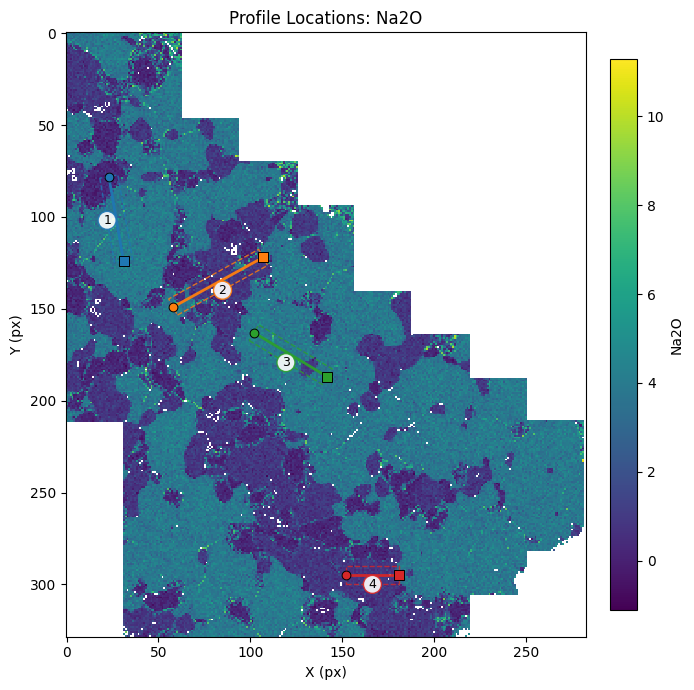

In [16]:
%matplotlib inline

fig, ax = mm.plot_locations(result, 
                            lp["coordinates_df"],
                            map_key="Na2O"
                            )

## 7. Batch extract profiles from saved transects

`mm.batch_extract_line_profiles` extracts profiles for multiple oxides at once from a saved transect table. Pass `lp["coordinates_df"]` from an interactive session, or any DataFrame with `x0`, `y0`, `x1`, `y1` columns.

Each oxide becomes its own column, making it easy to compare compositions along the same transect.

In [17]:
%matplotlib inline

profiles_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "Al2O3", "FeOt", "MgO", "CaO", "Feldspar.An"],
    method="none",
    pixel_size_um=4.0,
)

profiles_df

,profile_id,x,y,distance_px,perp_distance_px,distance_um,SiO2,SiO2_smoothed,Al2O3,Al2O3_smoothed,...,CaO,CaO_smoothed,Feldspar.An,Feldspar.An_smoothed,x0,y0,x1,y1,width_px,source
0,1,23.0,78.0,0.000000,0.000000,0.000000,52.931222,52.931222,6.645512,6.645512,...,0.835569,0.835569,NaN,NaN,23.0,78.0,31.0,124.0,10.0,auto
1,1,24.0,78.0,0.171341,-0.985212,0.685365,51.063888,51.063888,6.579941,6.579941,...,1.024854,1.024854,NaN,NaN,23.0,78.0,31.0,124.0,10.0,auto
2,1,19.0,79.0,0.299847,4.112188,1.199388,51.651112,51.651112,6.383930,6.383930,...,0.831782,0.831782,NaN,NaN,23.0,78.0,31.0,124.0,10.0,auto
3,1,25.0,78.0,0.342682,-1.970424,1.370729,52.636241,52.636241,5.860295,5.860295,...,0.841763,0.841763,NaN,NaN,23.0,78.0,31.0,124.0,10.0,auto
4,1,20.0,79.0,0.471188,3.126976,1.884753,49.918035,49.918035,7.178440,7.178440,...,1.050741,1.050741,NaN,NaN,23.0,78.0,31.0,124.0,10.0,auto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818,4,181.0,296.0,29.000000,1.000000,116.000000,30.579981,30.579981,20.910270,20.910270,...,42.409274,42.409274,NaN,NaN,152.0,295.0,181.0,295.0,10.0,auto
1819,4,181.0,297.0,29.000000,2.000000,116.000000,52.382828,52.382828,31.648497,31.648497,...,13.828002,13.828002,0.678470,0.678470,152.0,295.0,181.0,295.0,10.0,auto
1820,4,181.0,298.0,29.000000,3.000000,116.000000,50.760967,50.760967,30.961981,30.961981,...,13.428722,13.428722,0.664845,0.664845,152.0,295.0,181.0,295.0,10.0,auto
1821,4,181.0,299.0,29.000000,4.000000,116.000000,47.458011,47.458011,31.640987,31.640987,...,14.682268,14.682268,0.641940,0.641940,152.0,295.0,181.0,295.0,10.0,auto


In [18]:
# Long format — one row per oxide per distance bin, useful for plotting
profiles_df, profiles_long_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "MgO", "CaO"],
    method="mean",
    pixel_size_um=4.0,
    return_long=True,
)

profiles_long_df

,bin,distance_px,value,n_pixels,distance_um,value_smoothed,profile_id,key,source,x0,y0,x1,y1,width_px
0,0,0.050422,52.931222,1,0.201687,52.931222,1,SiO2,auto,23.0,78.0,31.0,124.0,10.0
1,1,0.151265,51.063888,1,0.605060,51.063888,1,SiO2,auto,23.0,78.0,31.0,124.0,10.0
2,2,0.252108,51.651112,1,1.008433,51.651112,1,SiO2,auto,23.0,78.0,31.0,124.0,10.0
3,3,0.352952,52.636241,1,1.411807,52.636241,1,SiO2,auto,23.0,78.0,31.0,124.0,10.0
4,4,0.453795,49.918035,1,1.815180,49.918035,1,SiO2,auto,23.0,78.0,31.0,124.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5326,283,28.546875,NaN,0,114.187500,NaN,4,CaO,auto,152.0,295.0,181.0,295.0,10.0
5327,284,28.647569,NaN,0,114.590278,NaN,4,CaO,auto,152.0,295.0,181.0,295.0,10.0
5328,285,28.748264,NaN,0,114.993056,NaN,4,CaO,auto,152.0,295.0,181.0,295.0,10.0
5329,286,28.848958,NaN,0,115.395833,NaN,4,CaO,auto,152.0,295.0,181.0,295.0,10.0


## 8. Composite component map

`mm.plot_component_composite` overlays continuous solid-solution compositions (e.g. plagioclase An%, olivine Fo%, pyroxene XMg) on top of a categorical phase map. This gives a single figure showing both phase identity and mineral chemistry.

The component maps are computed automatically by `run_map` and stored in `result["component_maps"]`.

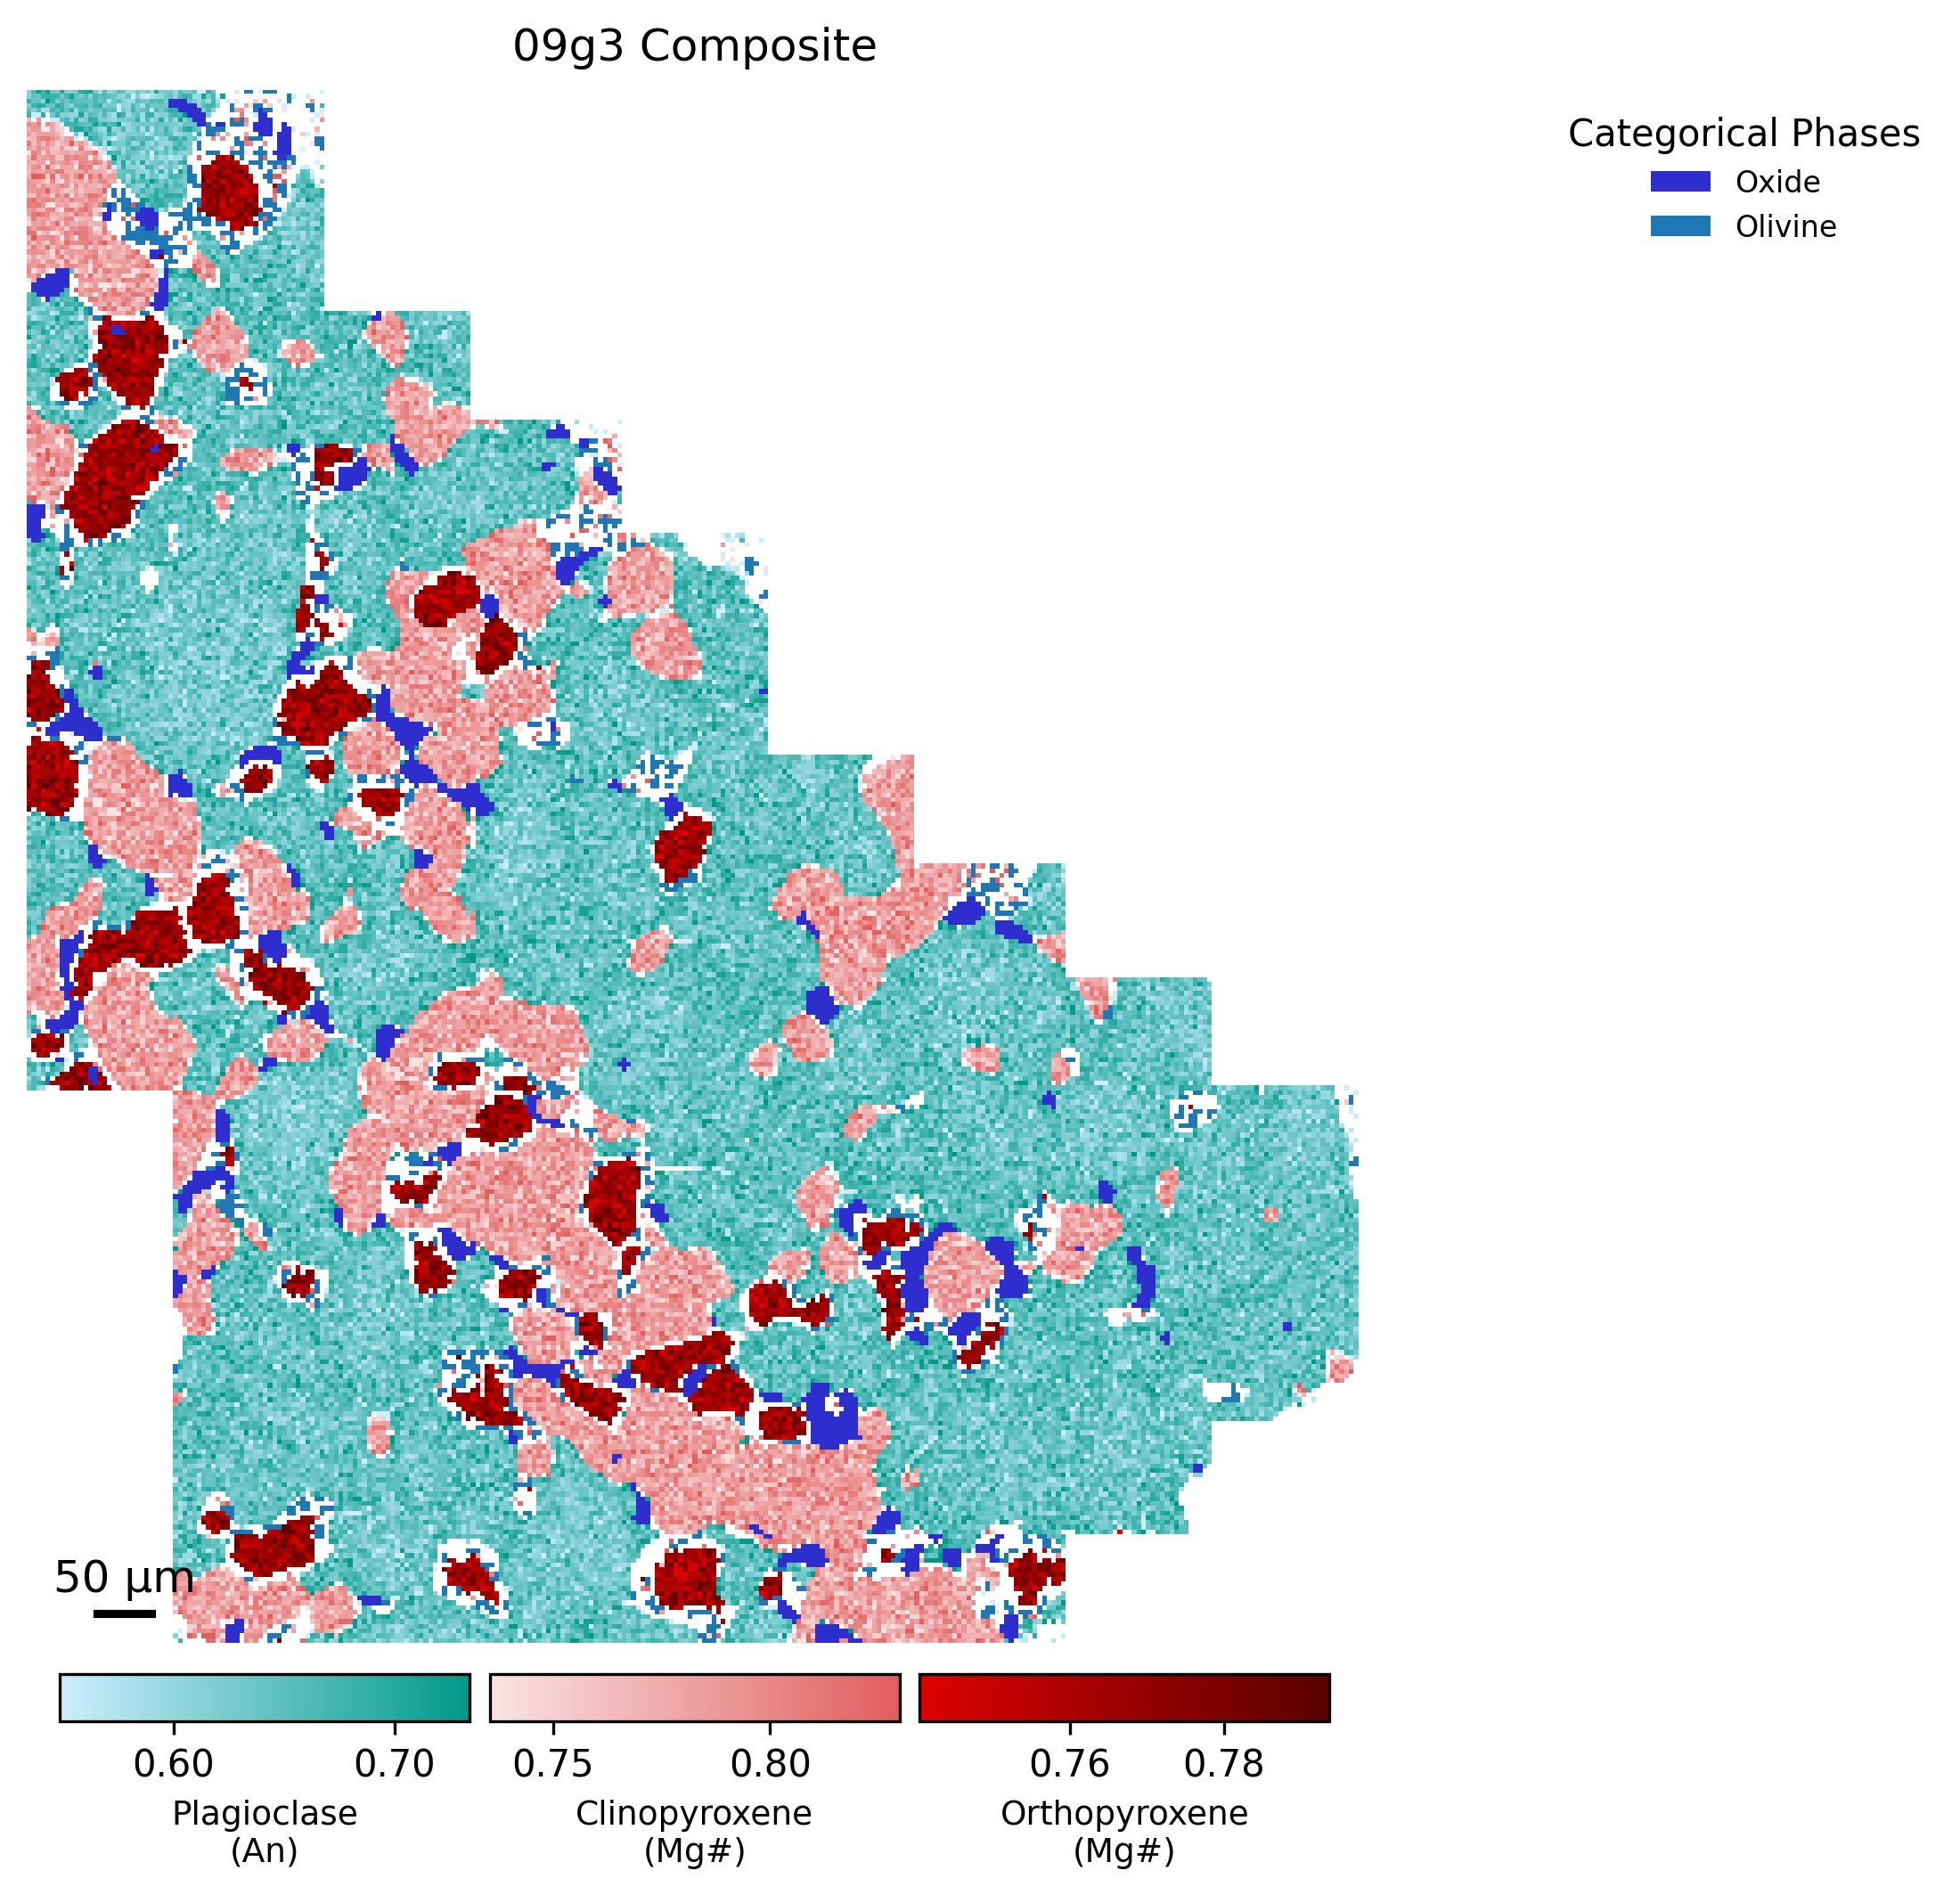

In [19]:
%matplotlib inline
# You can restrict which phases appear and adjust the color limits. `limits_mode="std"` clips the colorbar to the 2 sigma range of each component, which is useful when a few extreme pixels would otherwise compress the color scale.

fig, mineral_map, comp_maps = mm.plot_component_composite(
    result,
    title="09g3 Composite",
    pixel_size_um=4.0,
    scalebar_um=50,
    limits_mode="std", # 2 sigma range for color limits
)